In [24]:
import sys
sys.path.append("..")
import pandas as pd
import numpy as np
import sklearn as skl
from src.preprocessing.engenharia_features import engenharia_features
from src.modeling.otimizacao_hiperparametros import otimizar_hiperparametros
from src.evaluation.interpretabilidade import (
    plotar_curva_roc,
    calcular_shap_values,
    plotar_shap_summary,
    plotar_shap_bar,
)

# 1. Leitura da master table alunos_enriquecidos

In [37]:
df = pd.read_parquet(r'C:\dev\tech-challenge-fase3\data\alunos_enriquecido.parquet').drop(['ANO'], axis=1)

In [3]:
df.head()

,ano,id_municipio,id_escola,id_aluno,rede,alfabetizado,pct_in_biblioteca,pct_in_sala_leitura,pct_in_internet,pct_in_laboratorio_informatica,...,qtd_pes_acima_meio_sm_media,qtd_pes_pob_min,qtd_pes_baixa_renda_min,qtd_pes_acima_meio_sm_min,qtd_pes_pob_max,qtd_pes_baixa_renda_max,qtd_pes_acima_meio_sm_max,qtd_pes_pob_desvio_padrao,qtd_pes_baixa_renda_desvio_padrao,qtd_pes_acima_meio_sm_desvio_padrao
0,2023,330070,60025977,33014516,Municipal,1,0.357143,0.649351,0.993506,0.311688,...,15008.3,59740,16977,9130,68077,20868,19074,3069.361036,1507.987699,4148.806041
1,2023,312160,60021971,31008498,Municipal,1,0.804878,0.121951,0.975610,0.487805,...,7293.5,11687,8354,4478,14705,9407,9245,1315.642370,380.101171,1992.772510
2,2023,315780,60018571,31151092,Estadual,1,0.765432,0.197531,1.000000,0.358025,...,20555.5,46111,25722,10641,60477,27113,26625,6171.184418,489.561527,6795.470849
3,2023,420480,60035456,42032360,Municipal,1,0.777778,0.083333,1.000000,0.583333,...,5802.6,5868,4693,3917,7909,5432,6906,869.306550,278.190662,1242.301198
4,2023,420480,60035456,42032357,Municipal,1,0.777778,0.083333,1.000000,0.583333,...,5802.6,5868,4693,3917,7909,5432,6906,869.306550,278.190662,1242.301198


In [4]:
df.shape

(3355822, 44)

# 2. Aplicando engenharia de Feats

In [5]:
df_final = engenharia_features(df)

print(f"Colunas antes: {df.shape[1]}")
print(f"Colunas depois: {df_final.shape[1]}")
print(df.columns.tolist())

Colunas antes: 44
Colunas depois: 24
['ano', 'id_municipio', 'id_escola', 'id_aluno', 'rede', 'alfabetizado', 'pct_in_biblioteca', 'pct_in_sala_leitura', 'pct_in_internet', 'pct_in_laboratorio_informatica', 'pct_in_agua_potavel', 'pct_in_energia_inexistente', 'pct_in_esgoto_inexistente', 'pct_in_alimentacao', 'pct_in_acessibilidade_corrimao', 'pct_in_acessibilidade_elevador', 'pct_in_acessibilidade_pisos_tateis', 'pct_in_acessibilidade_vao_livre', 'pct_in_acessibilidade_rampas', 'pct_in_acessibilidade_sinal_sonoro', 'pct_in_acessibilidade_sinal_tatil', 'pct_in_acessibilidade_sinal_visual', 'pct_in_banheiro_pne', 'pct_in_material_ped_infantil', 'pct_in_material_ped_cientifico', 'pct_in_material_ped_jogos', 'pct_in_material_ped_artisticas', 'pct_in_material_ped_multimidia', 'pct_in_educacao_indigena', 'qt_mat_bas_media', 'qt_salas_media', 'n_escolas', 'qtd_pes_pob_media', 'qtd_pes_baixa_renda_media', 'qtd_pes_acima_meio_sm_media', 'qtd_pes_pob_min', 'qtd_pes_baixa_renda_min', 'qtd_pes_ac

In [6]:
df_final.head()

,ano,id_municipio,id_escola,id_aluno,rede,alfabetizado,pct_in_biblioteca,pct_in_sala_leitura,pct_in_internet,pct_in_laboratorio_informatica,...,qtd_pes_baixa_renda_media,qtd_pes_acima_meio_sm_media,indice_acessibilidade,indice_material_pedagogico,indice_infra_basica,alunos_por_sala,log_n_escolas,qtd_pes_pob_cv,qtd_pes_baixa_renda_cv,qtd_pes_acima_meio_sm_cv
0,2023,330070,60025977,33014516,Municipal,1,0.357143,0.649351,0.993506,0.311688,...,19228.7,15008.3,0.224838,0.545455,0.997835,31.938874,5.159055,0.048764,0.078424,0.276434
1,2023,312160,60021971,31008498,Municipal,1,0.804878,0.121951,0.975610,0.487805,...,8724.7,7293.5,0.219512,0.478049,0.983740,26.491841,4.521789,0.102960,0.043566,0.273226
2,2023,315780,60018571,31151092,Estadual,1,0.765432,0.197531,1.000000,0.358025,...,26492.6,20555.5,0.273148,0.469136,1.000000,39.926496,4.605170,0.119689,0.018479,0.330591
3,2023,420480,60035456,42032360,Municipal,1,0.777778,0.083333,1.000000,0.583333,...,4978.6,5802.6,0.343750,0.566667,1.000000,28.947428,3.688879,0.131234,0.055877,0.214094
4,2023,420480,60035456,42032357,Municipal,1,0.777778,0.083333,1.000000,0.583333,...,4978.6,5802.6,0.343750,0.566667,1.000000,28.947428,3.688879,0.131234,0.055877,0.214094


In [7]:
print(df_final.dtypes)

ano                                 int32
id_municipio                        int64
id_escola                           int64
id_aluno                            int64
rede                                  str
alfabetizado                        int64
pct_in_biblioteca                 float64
pct_in_sala_leitura               float64
pct_in_internet                   float64
pct_in_laboratorio_informatica    float64
pct_in_alimentacao                float64
pct_in_banheiro_pne               float64
pct_in_educacao_indigena          float64
qtd_pes_pob_media                 float64
qtd_pes_baixa_renda_media         float64
qtd_pes_acima_meio_sm_media       float64
indice_acessibilidade             float64
indice_material_pedagogico        float64
indice_infra_basica               float64
alunos_por_sala                   float64
log_n_escolas                     float64
qtd_pes_pob_cv                    float64
qtd_pes_baixa_renda_cv            float64
qtd_pes_acima_meio_sm_cv          

In [29]:
df_final.to_parquet(
    fr"C:\dev\tech-challenge-fase3\data\df_final.parquet",
    index=False
)

Foi aplicado agregacoes com sentido estrutural de cada grupo de feat para não trabalhar com valores absolutos.

# 3. Separação de Treino e Teste

In [8]:
colunas_id = ["id_aluno", "id_escola", "id_municipio", "ano"]
coluna_target = "alfabetizado"

colunas_categoricas = ["rede"]

colunas_numericas = [
    col for col in df_final.columns
    if col not in colunas_id + colunas_categoricas + [coluna_target]
]

print(f"Numéricas: {len(colunas_numericas)}")
print(f"Categóricas: {len(colunas_categoricas)}")

Numéricas: 18
Categóricas: 1


In [9]:
from sklearn.model_selection import train_test_split

X = df_final[colunas_numericas + colunas_categoricas]
y = df_final[coluna_target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # garante mesma proporção de alfabetizado/não-alfabetizado nos dois conjuntos
)

print(f"Treino: {X_train.shape}")
print(f"Teste: {X_test.shape}")
print(f"Proporção do target (treino):\n{y_train.value_counts(normalize=True)}")
print(f"Proporção do target (teste):\n{y_test.value_counts(normalize=True)}")

Treino: (2684657, 19)
Teste: (671165, 19)
Proporção do target (treino):
alfabetizado
1    0.591369
0    0.408631
Name: proportion, dtype: float64
Proporção do target (teste):
alfabetizado
1    0.591369
0    0.408631
Name: proportion, dtype: float64


A target esta levemente desbalanceada. Tratamos este problema na tunagem do modelo.

In [10]:
df = df_final.drop(colunas_id, axis=1)

In [11]:
df.head()

,rede,alfabetizado,pct_in_biblioteca,pct_in_sala_leitura,pct_in_internet,pct_in_laboratorio_informatica,pct_in_alimentacao,pct_in_banheiro_pne,pct_in_educacao_indigena,qtd_pes_pob_media,qtd_pes_baixa_renda_media,qtd_pes_acima_meio_sm_media,indice_acessibilidade,indice_material_pedagogico,indice_infra_basica,alunos_por_sala,log_n_escolas,qtd_pes_pob_cv,qtd_pes_baixa_renda_cv,qtd_pes_acima_meio_sm_cv
0,Municipal,1,0.357143,0.649351,0.993506,0.311688,0.720779,0.636364,0.0,62943.5,19228.7,15008.3,0.224838,0.545455,0.997835,31.938874,5.159055,0.048764,0.078424,0.276434
1,Municipal,1,0.804878,0.121951,0.975610,0.487805,0.853659,0.536585,0.0,12778.2,8724.7,7293.5,0.219512,0.478049,0.983740,26.491841,4.521789,0.102960,0.043566,0.273226
2,Estadual,1,0.765432,0.197531,1.000000,0.358025,0.802469,0.851852,0.0,51560.3,26492.6,20555.5,0.273148,0.469136,1.000000,39.926496,4.605170,0.119689,0.018479,0.330591
3,Municipal,1,0.777778,0.083333,1.000000,0.583333,0.861111,0.694444,0.0,6624.1,4978.6,5802.6,0.343750,0.566667,1.000000,28.947428,3.688879,0.131234,0.055877,0.214094
4,Municipal,1,0.777778,0.083333,1.000000,0.583333,0.861111,0.694444,0.0,6624.1,4978.6,5802.6,0.343750,0.566667,1.000000,28.947428,3.688879,0.131234,0.055877,0.214094


In [12]:
df.shape

(3355822, 20)

# 4. Treinando o Modelo

In [13]:
import sys
sys.path.append("..")
from src.modeling.treinamento_modelo import treinar_modelo
from src.evaluation.avaliacao_modelo import avaliar_modelo


resultado = treinar_modelo(
    df=df,
    colunas_numericas=colunas_numericas,
    colunas_categoricas=colunas_categoricas,
    coluna_target="alfabetizado",
)

metricas = avaliar_modelo(resultado)

[LightGBM] [Info] Number of positive: 1587624, number of negative: 1097033
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.154039 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4498
[LightGBM] [Info] Number of data points in the train set: 2684657, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.591369 -> initscore=0.369629
[LightGBM] [Info] Start training from score 0.369629
                  precision    recall  f1-score   support

não alfabetizado       0.59      0.32      0.41    274259
    alfabetizado       0.64      0.85      0.73    396906

        accuracy                           0.63    671165
       macro avg       0.62      0.58      0.57    671165
    weighted avg       0.62      0.63      0.60    671165

ROC-AUC: 0.6540


In [14]:
# testando para ver se vai rodar sem erro
busca = otimizar_hiperparametros(
    X_train=resultado["X_train"],
    y_train=resultado["y_train"],
    colunas_numericas=colunas_numericas,
    colunas_categoricas=colunas_categoricas,
    frac_amostra=0.05,
    n_candidates=5,
)

n_iterations: 2
n_required_iterations: 2
n_possible_iterations: 2
min_resources_: 44744
max_resources_: 134232
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 5
n_resources: 44744
Fitting 3 folds for each of 5 candidates, totalling 15 fits
----------
iter: 1
n_candidates: 2
n_resources: 134232
Fitting 3 folds for each of 2 candidates, totalling 6 fits
[LightGBM] [Info] Number of positive: 79381, number of negative: 54851
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021145 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4496
[LightGBM] [Info] Number of data points in the train set: 134232, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.591372 -> initscore=0.369639
[LightGBM] [Info] Start training from score 0.369639
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

como executou para uma amostra bem pequena, testar aumentando gradualmente os recursos até obter teto de ganho

In [15]:
# começando a busca de hiperparâmetros com job 2 e resource 500 mil
busca = otimizar_hiperparametros(
    X_train=resultado["X_train"],
    y_train=resultado["y_train"],
    colunas_numericas=colunas_numericas,
    colunas_categoricas=colunas_categoricas,
    n_jobs=2,
    max_resources=500_000,
)

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 18518
max_resources_: 500000
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 40
n_resources: 18518
Fitting 3 folds for each of 40 candidates, totalling 120 fits
----------
iter: 1
n_candidates: 14
n_resources: 55554
Fitting 3 folds for each of 14 candidates, totalling 42 fits
----------
iter: 2
n_candidates: 5
n_resources: 166662
Fitting 3 folds for each of 5 candidates, totalling 15 fits
----------
iter: 3
n_candidates: 2
n_resources: 499986
Fitting 3 folds for each of 2 candidates, totalling 6 fits
[LightGBM] [Info] Number of positive: 1587624, number of negative: 1097033
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.389397 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4498
[LightGBM] [Info] Number of data points in the train set: 2684657, number of used features: 20
[LightGBM] [Info] [bi

In [16]:
#  busca de hiperparâmetros com job 4 e resource 1_000_000 mil
busca = otimizar_hiperparametros(
    X_train=resultado["X_train"],
    y_train=resultado["y_train"],
    colunas_numericas=colunas_numericas,
    colunas_categoricas=colunas_categoricas,
    n_jobs=4,
    max_resources=1_000_000,
)

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 37037
max_resources_: 1000000
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 40
n_resources: 37037
Fitting 3 folds for each of 40 candidates, totalling 120 fits
----------
iter: 1
n_candidates: 14
n_resources: 111111
Fitting 3 folds for each of 14 candidates, totalling 42 fits
----------
iter: 2
n_candidates: 5
n_resources: 333333
Fitting 3 folds for each of 5 candidates, totalling 15 fits
----------
iter: 3
n_candidates: 2
n_resources: 999999
Fitting 3 folds for each of 2 candidates, totalling 6 fits
[LightGBM] [Info] Number of positive: 1587624, number of negative: 1097033
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.372420 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4498
[LightGBM] [Info] Number of data points in the train set: 2684657, number of used features: 20
[LightGBM] [Info] [

In [17]:
# avaliando resultados

resultado_otimizado = {
    "pipeline": busca.best_estimator_,
    "X_train": resultado["X_train"],
    "X_test": resultado["X_test"],
    "y_train": resultado["y_train"],
    "y_test": resultado["y_test"],
}

metricas_otimizadas = avaliar_modelo(resultado_otimizado)

                  precision    recall  f1-score   support

não alfabetizado       0.53      0.62      0.57    274259
    alfabetizado       0.70      0.62      0.66    396906

        accuracy                           0.62    671165
       macro avg       0.62      0.62      0.62    671165
    weighted avg       0.63      0.62      0.62    671165

ROC-AUC: 0.6713


In [14]:
# testando com espacos de refinamento mais amplos
espaco_refinado = {
    "modelo__n_estimators": [200, 300, 400],
    "modelo__num_leaves": [47, 63, 90],
    "modelo__max_depth": [-1],
    "modelo__learning_rate": [0.03, 0.05, 0.08],
    "modelo__min_child_samples": [20, 30, 50],
    "modelo__subsample": [0.8, 0.9, 1.0],
    "modelo__colsample_bytree": [0.6, 0.7, 0.8],
    "modelo__reg_alpha": [1, 5, 10],
    "modelo__reg_lambda": [0.1, 0.5, 1],
    "modelo__is_unbalance": [True],
}

busca_refinada = otimizar_hiperparametros(
    X_train=resultado["X_train"],
    y_train=resultado["y_train"],
    colunas_numericas=colunas_numericas,
    colunas_categoricas=colunas_categoricas,
    espaco_parametros=espaco_refinado,
    n_jobs=4,
    max_resources=1_500_000,
)

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 55555
max_resources_: 1500000
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 40
n_resources: 55555
Fitting 3 folds for each of 40 candidates, totalling 120 fits
----------
iter: 1
n_candidates: 14
n_resources: 166665
Fitting 3 folds for each of 14 candidates, totalling 42 fits
----------
iter: 2
n_candidates: 5
n_resources: 499995
Fitting 3 folds for each of 5 candidates, totalling 15 fits
----------
iter: 3
n_candidates: 2
n_resources: 1499985
Fitting 3 folds for each of 2 candidates, totalling 6 fits
[LightGBM] [Info] Number of positive: 1587624, number of negative: 1097033
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.142913 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4498
[LightGBM] [Info] Number of data points in the tr

In [16]:
# avaliando resultados com max_resources=1_500_000,

resultado_otimizado = {
    "pipeline": busca_refinada.best_estimator_,
    "X_train": resultado["X_train"],
    "X_test": resultado["X_test"],
    "y_train": resultado["y_train"],
    "y_test": resultado["y_test"],
}

metricas_otimizadas = avaliar_modelo(resultado_otimizado)

                  precision    recall  f1-score   support

não alfabetizado       0.53      0.62      0.57    274259
    alfabetizado       0.70      0.62      0.66    396906

        accuracy                           0.62    671165
       macro avg       0.62      0.62      0.62    671165
    weighted avg       0.63      0.62      0.62    671165

ROC-AUC: 0.6708


In [18]:
# verificando parametros como min child samples e reg alpha

espaco_teste_borda = {
    "modelo__n_estimators": [300],
    "modelo__num_leaves": [63],
    "modelo__max_depth": [-1],
    "modelo__learning_rate": [0.05],
    "modelo__min_child_samples": [10, 15, 20],
    "modelo__subsample": [1.0],
    "modelo__colsample_bytree": [0.6],
    "modelo__reg_alpha": [10, 15, 20],
    "modelo__reg_lambda": [0.5],
    "modelo__is_unbalance": [True],
}

# modelo__min_child_samples e modelo__reg_alpha
busca_refinada_mcs_ra = otimizar_hiperparametros(
    X_train=resultado["X_train"],
    y_train=resultado["y_train"],
    colunas_numericas=colunas_numericas,
    colunas_categoricas=colunas_categoricas,
    espaco_parametros=espaco_refinado,
    n_jobs=4,
    max_resources=1_500_000,
)

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 55555
max_resources_: 1500000
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 40
n_resources: 55555
Fitting 3 folds for each of 40 candidates, totalling 120 fits
----------
iter: 1
n_candidates: 14
n_resources: 166665
Fitting 3 folds for each of 14 candidates, totalling 42 fits
----------
iter: 2
n_candidates: 5
n_resources: 499995
Fitting 3 folds for each of 5 candidates, totalling 15 fits
----------
iter: 3
n_candidates: 2
n_resources: 1499985
Fitting 3 folds for each of 2 candidates, totalling 6 fits
[LightGBM] [Info] Number of positive: 1587624, number of negative: 1097033
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.147942 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4498
[LightGBM] [Info] Number of data points in the tr

In [19]:
resultado_otimizado = {
    "pipeline": busca_refinada_mcs_ra.best_estimator_,
    "X_train": resultado["X_train"],
    "X_test": resultado["X_test"],
    "y_train": resultado["y_train"],
    "y_test": resultado["y_test"],
}

metricas_otimizadas = avaliar_modelo(resultado_otimizado)

                  precision    recall  f1-score   support

não alfabetizado       0.53      0.62      0.57    274259
    alfabetizado       0.70      0.62      0.66    396906

        accuracy                           0.62    671165
       macro avg       0.62      0.62      0.62    671165
    weighted avg       0.63      0.62      0.62    671165

ROC-AUC: 0.6708


Comparando o resultado do baseline com a tunagem de hiperparametros, sacrificando um pouco a acuracia, conseguimos equilibrar melhor o recall das duas classes. Dado que acertar os não alfabetizados e tão importante quanto saber os alfabetizados no contexto de tomar decisões para previnir a taxa alta de não alfabetizados.

De 32% e 0.85% de recall para não alfabetizados e alfabetizados, respectivamentes, fomos para 62% ambos, abrindo mão de 1% de acuracia.
A curva RoC foi de 65% para 67%.

Dado que aumentar mais os recursos para a tunagem estavam demonstrando pouco ganho, decidimos usar somente o busca refinada para melhores parametros.

In [20]:
modelo_final = busca_refinada.best_estimator_.named_steps["modelo"]
nomes_features = busca_refinada.best_estimator_.named_steps["preprocessamento"].get_feature_names_out()

importancias = pd.Series(modelo_final.feature_importances_, index=nomes_features).sort_values(ascending=False)
importancias.head(15)

num__qtd_pes_pob_media                 1264
num__pct_in_sala_leitura               1260
num__pct_in_biblioteca                 1191
num__alunos_por_sala                   1189
num__pct_in_banheiro_pne               1167
num__pct_in_laboratorio_informatica    1163
num__indice_material_pedagogico        1156
num__indice_acessibilidade             1130
num__qtd_pes_pob_cv                    1101
num__qtd_pes_baixa_renda_cv            1099
num__qtd_pes_acima_meio_sm_cv          1078
num__log_n_escolas                     1070
num__pct_in_alimentacao                1055
num__qtd_pes_baixa_renda_media         1001
num__qtd_pes_acima_meio_sm_media        892
dtype: int32

In [21]:
# rodando importance feat com importance_type="gain"

modelo_final = busca_refinada.best_estimator_.named_steps["modelo"]
nomes_features = busca_refinada.best_estimator_.named_steps["preprocessamento"].get_feature_names_out()

# não precisa retreinar -- o booster já guarda os dois tipos de importância
importancia_gain = modelo_final.booster_.feature_importance(importance_type="gain")

pd.Series(importancia_gain, index=nomes_features).sort_values(ascending=False).head(15)

num__qtd_pes_pob_media                 234766.686234
num__pct_in_laboratorio_informatica    232111.852684
num__indice_infra_basica               225384.664769
num__indice_material_pedagogico        219743.948861
num__pct_in_biblioteca                 211593.164636
num__pct_in_internet                   198525.967808
num__pct_in_sala_leitura               193711.383313
num__alunos_por_sala                   191817.171385
num__pct_in_alimentacao                188358.253175
num__pct_in_banheiro_pne               150920.120429
num__qtd_pes_acima_meio_sm_cv          145868.948601
num__indice_acessibilidade             145793.502507
num__log_n_escolas                     136010.798327
num__qtd_pes_pob_cv                    129647.199760
num__qtd_pes_baixa_renda_media         127578.358289
dtype: float64

In [22]:
df[[
    "qtd_pes_pob_cv", "qtd_pes_baixa_renda_cv", "qtd_pes_acima_meio_sm_cv",
    "pct_in_sala_leitura", "pct_in_biblioteca",
]].corr()

,qtd_pes_pob_cv,qtd_pes_baixa_renda_cv,qtd_pes_acima_meio_sm_cv,pct_in_sala_leitura,pct_in_biblioteca
qtd_pes_pob_cv,1.000000,0.246335,0.660042,-0.117546,0.304352
qtd_pes_baixa_renda_cv,0.246335,1.000000,0.441894,-0.188256,-0.106377
qtd_pes_acima_meio_sm_cv,0.660042,0.441894,1.000000,-0.035918,0.130102
pct_in_sala_leitura,-0.117546,-0.188256,-0.035918,1.000000,-0.031329
pct_in_biblioteca,0.304352,-0.106377,0.130102,-0.031329,1.000000


# 5. Interpretabilidade

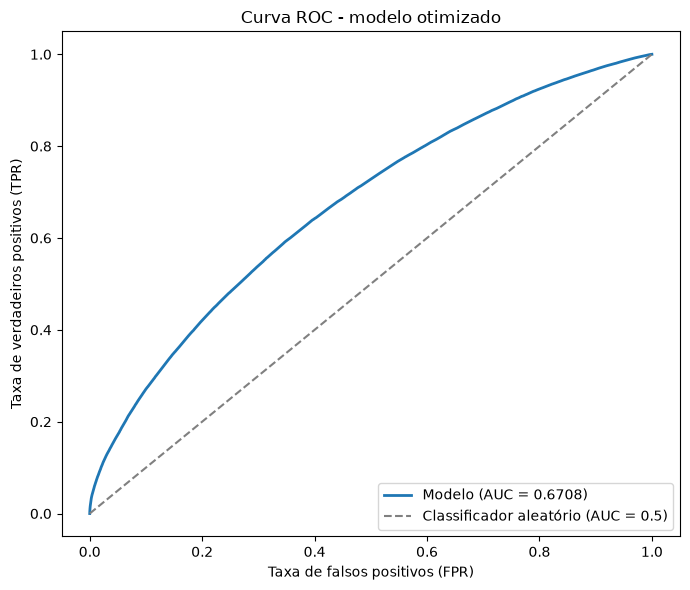

0.6707883126103102

In [25]:
# interpretabilidade - curva roc
resultado_otimizado = {
    "pipeline": busca_refinada.best_estimator_,
    "X_test": resultado["X_test"],
    "y_test": resultado["y_test"],
}

plotar_curva_roc(resultado_otimizado, titulo="Curva ROC - modelo otimizado")

In [26]:
explicacao = calcular_shap_values(busca_refinada.best_estimator_, resultado["X_test"])

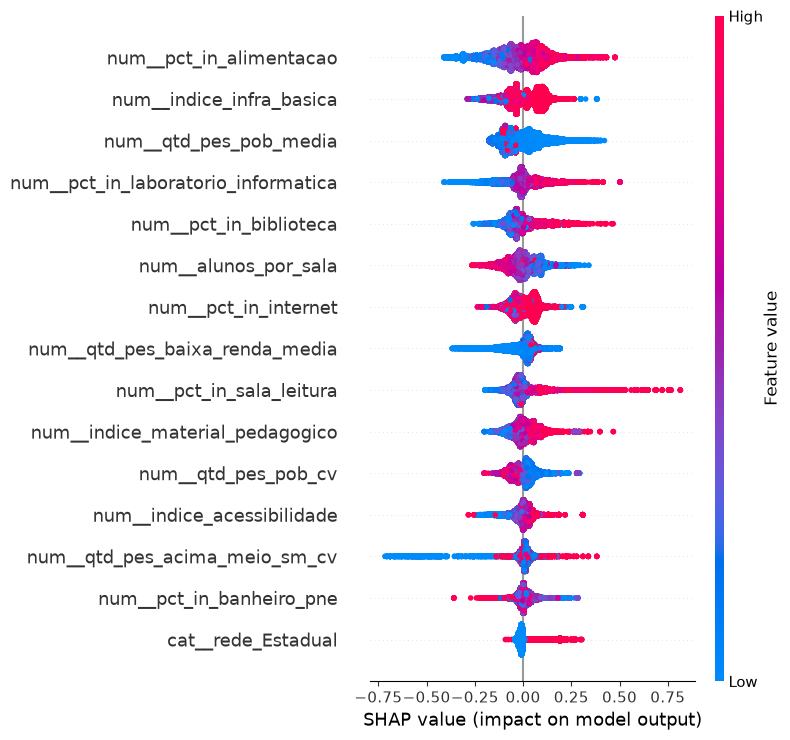

In [27]:
plotar_shap_summary(explicacao)

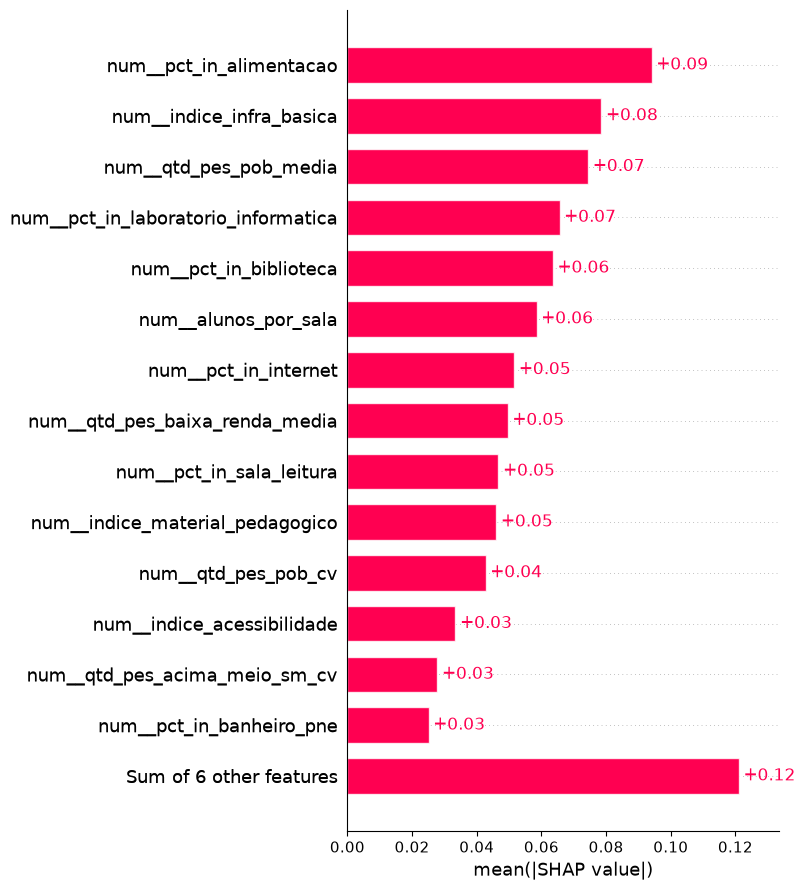

In [28]:
plotar_shap_bar(explicacao)

Na interpretabilidade alimentacao, infra basica, laboratorios de informatica, bibliotecas e quantidade de alunos por sala, demonstraram sentidos coerentes como quanto maior a infra basica do aluno, maiors a probabilidade dele ser alfabetizado, assim como maior alimentação e quantidade de laboratorios de informatica. No sentido contrario, quanto maior o numero de alunos em sala de aula maior a probabilidade de não ser alfabetizado.

# 6. Perguntas de negocio

## Quais fatores mais impactam a alfabetização e Quais variáveis possuem maior influência no modelo?
Alimentação escolar, infraestrutura basica, contexto socioeconomico da regiao, recursos como laboratorios de informatica e bibliotecas, superlotacao da sala de aula e redes de ensino.

# Quais municípios apresentam maior risco educacional?

In [36]:
# leitura df que contem peso aluno
ANOS = [2023, 2024]
df_peso = pd.concat([
    pd.read_parquet(f"../data/silver/integrado/year={ano}/dados.parquet")
    for ano in ANOS
], ignore_index=True)

In [41]:
df_peso.columns

Index(['ano', 'id_municipio', 'id_escola', 'id_aluno', 'caderno', 'serie',
       'rede', 'presenca', 'preenchimento_caderno', 'alfabetizado',
       'proficiencia', 'peso_aluno', 'sigla_uf', 'regiao',
       'mun_taxa_alfabetizacao', 'mun_media_portugues', 'mun_prop_nivel_0',
       'mun_prop_nivel_1', 'mun_prop_nivel_2', 'mun_prop_nivel_3',
       'mun_prop_nivel_4', 'mun_prop_nivel_5', 'mun_prop_nivel_6',
       'mun_prop_nivel_7', 'mun_prop_nivel_8', 'mun_nivel_alfabetizacao',
       'mun_percentual_participacao', 'gap_mun_meta_2030',
       'uf_taxa_alfabetizacao', 'uf_media_portugues', 'gap_mun_vs_uf'],
      dtype='str')

In [38]:
peso_aluno = (
    df_peso[["ano", "id_aluno", "peso_aluno","sigla_uf","regiao"]]
    .drop_duplicates(["ano", "id_aluno"])
)

df = df.merge(
    peso_aluno,
    on=["ano", "id_aluno"],
    how="left",
    validate="many_to_one",
)

print(f"Valores ausentes em peso_aluno: {df['peso_aluno'].isna().sum()}")
df[["ano", "id_aluno", "peso_aluno"]].head()

Valores ausentes em peso_aluno: 1185


,ano,id_aluno,peso_aluno
0,2023,33014516,0.310110
1,2023,31008498,0.452510
2,2023,31151092,0.545775
3,2023,42032360,0.585886
4,2023,42032357,0.585886


In [39]:
df.head()

,ano,id_municipio,id_escola,id_aluno,rede,alfabetizado,pct_in_biblioteca,pct_in_sala_leitura,pct_in_internet,pct_in_laboratorio_informatica,...,qtd_pes_pob_min,qtd_pes_baixa_renda_min,qtd_pes_acima_meio_sm_min,qtd_pes_pob_max,qtd_pes_baixa_renda_max,qtd_pes_acima_meio_sm_max,qtd_pes_pob_desvio_padrao,qtd_pes_baixa_renda_desvio_padrao,qtd_pes_acima_meio_sm_desvio_padrao,peso_aluno
0,2023,330070,60025977,33014516,Municipal,1,0.357143,0.649351,0.993506,0.311688,...,59740,16977,9130,68077,20868,19074,3069.361036,1507.987699,4148.806041,0.310110
1,2023,312160,60021971,31008498,Municipal,1,0.804878,0.121951,0.975610,0.487805,...,11687,8354,4478,14705,9407,9245,1315.642370,380.101171,1992.772510,0.452510
2,2023,315780,60018571,31151092,Estadual,1,0.765432,0.197531,1.000000,0.358025,...,46111,25722,10641,60477,27113,26625,6171.184418,489.561527,6795.470849,0.545775
3,2023,420480,60035456,42032360,Municipal,1,0.777778,0.083333,1.000000,0.583333,...,5868,4693,3917,7909,5432,6906,869.306550,278.190662,1242.301198,0.585886
4,2023,420480,60035456,42032357,Municipal,1,0.777778,0.083333,1.000000,0.583333,...,5868,4693,3917,7909,5432,6906,869.306550,278.190662,1242.301198,0.585886


In [40]:
X_test_com_id = df.loc[resultado["X_test"].index, ["id_municipio", "peso_aluno"]].copy()
X_test_com_id["prob_nao_alfabetizado"] = 1 - busca_refinada.best_estimator_.predict_proba(resultado["X_test"])[:, 1]

risco_por_municipio = (
    X_test_com_id
    .groupby("id_municipio")
    .apply(lambda g: (g["prob_nao_alfabetizado"] * g["peso_aluno"]).sum() / g["peso_aluno"].sum())
    .sort_values(ascending=False)
)

risco_por_municipio.head(20)  # municípios de maior risco médio, segundo o modelo

id_municipio
290720    0.837522
280480    0.781456
150280    0.777023
150520    0.774469
291060    0.758535
280560    0.757301
292440    0.756242
280360    0.755791
290220    0.755636
293015    0.755388
270360    0.754225
290270    0.754036
280270    0.751072
292575    0.750978
290530    0.750661
293050    0.747556
160050    0.746641
280170    0.746340
292400    0.745930
291840    0.742929
dtype: float64

# Como prever municípios que podem não atingir metas futuras?